### Baseline Comparison: fMRI upper-tri vs sMRI node features (GNN cache split)
Ridge / SVR / XGBoost on the exact same train/val/test split used in MAHGCN.

In [1]:
import random, json as _json
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error
import os

dir_path = r"C:\Users\Faruk\Code\CCIR_Project"

with open(rf"{dir_path}\saved_variables.json") as f:
    _sd = _json.load(f)

# Replicate get_meta_data("NKItrimmed_BHRC_HBN_CCNP", "PNC") exactly
_train_studies, _test_studies = "NKItrimmed_BHRC_HBN_PNC", "CCNP"
_all_train, _test_ids, _dfs = [], [], []

# Csv to save the results
results_csv = rf"{dir_path}\BaselineExperiments\LOO_{_test_studies}\results_table.csv"

for _s in _train_studies.split("_"):
    _bs = "NKI" if _s == "NKItrimmed" else _s
    _subs = (_sd.get(f"{_s.lower()}_age_trainval_subjects", []) +
             _sd.get(f"{_s.lower()}_age_test_subjects", []))
    _all_train.extend([f"{_bs}_{sid}" for sid in _subs])
    _df = pd.read_csv(rf"{dir_path}\{_bs}_BIDS\study-{_bs}_desc-participants.tsv", sep="\t")
    if _bs == "NKI":
        _df = _df[["participant_id", "session_id", "age"]].dropna(subset=["age"])
        _df["participant_id"] = "NKI_" + _df["participant_id"].astype(str) + "-" + _df["session_id"].astype(str)
    else:
        _df = _df.drop_duplicates("participant_id")[["participant_id", "age"]]
        _df["participant_id"] = _bs + "_" + _df["participant_id"].astype(str)
    _dfs.append(_df)

for _s in _test_studies.split("_"):
    _bs = "NKI" if _s == "NKItrimmed" else _s
    _subs = (_sd.get(f"{_s.lower()}_age_trainval_subjects", []) +
             _sd.get(f"{_s.lower()}_age_test_subjects", []))
    _test_ids.extend([f"{_bs}_{sid}" for sid in _subs])
    _df = pd.read_csv(rf"{dir_path}\{_bs}_BIDS\study-{_bs}_desc-participants.tsv", sep="\t")
    if _bs == "NKI":
        _df = _df[["participant_id", "session_id", "age"]].dropna(subset=["age"])
        _df["participant_id"] = "NKI_" + _df["participant_id"].astype(str) + "-" + _df["session_id"].astype(str)
    else:
        _df = _df.drop_duplicates("participant_id")[["participant_id", "age"]]
        _df["participant_id"] = _bs + "_" + _df["participant_id"].astype(str)
    _dfs.append(_df)

_age_lookup = pd.concat(_dfs).drop_duplicates("participant_id").set_index("participant_id")["age"]
random.seed(42)
random.shuffle(_all_train)
_split = int(len(_all_train) * 0.9)
train_ids_bl = _all_train[:_split]
val_ids_bl   = _all_train[_split:]
test_ids_bl  = _test_ids

y_train_bl = _age_lookup.loc[train_ids_bl].values
y_val_bl   = _age_lookup.loc[val_ids_bl].values
y_test_bl  = _age_lookup.loc[test_ids_bl].values

print(f"Train n={len(train_ids_bl)}, Val n={len(val_ids_bl)}, Test n={len(test_ids_bl)}")
print(f"Train ages {y_train_bl.min():.1f}-{y_train_bl.max():.1f}")

Train n=2441, Val n=272, Test n=151
Train ages 5.7-23.0


In [2]:
from collections import defaultdict

# Load the fMRI&sMRI caches 
_cache_dir = rf"{dir_path}\cache_gen\cache"
_keys = [f"per_{per}_{_train_studies}_{_test_studies}_fMRI&sMRI_300" for per in ["10", "20", "50"]]

splits = defaultdict(lambda: defaultdict(dict))

for _key, _per in zip(_keys, ["10", "20", "50"]):
    _cached_ids = _json.load(open(rf"{_cache_dir}\{_key}_subjects.json"))
    _cache_idx  = {sid: i for i, sid in enumerate(_cached_ids)}
    _fc_cache  = np.load(rf"{_cache_dir}\{_key}_fMRI.npy")   # (N, 300, 300)
    _smri_cache = np.load(rf"{_cache_dir}\{_key}_sMRI.npy")   # (N, 300, 7)
    print(f"FC cache: {_fc_cache.shape},  sMRI cache: {_smri_cache.shape}")

    _triu = np.triu_indices(300, k=1)   # 44850 upper-triangular edges

    def _feat(ids, kind):
        idx = [_cache_idx[s] for s in ids]
        _fc_data = _fc_cache[idx][:, _triu[0], _triu[1]] # (N, 44850)
        _smri_data = _smri_cache[idx].reshape(len(idx), -1) # (N, 1200)
        if kind == "fmri":
            return _fc_data   
        return np.concatenate([_fc_data, _smri_data], axis=1)     

    X_tr_fmri = _feat(train_ids_bl, "fmri");  X_vl_fmri = _feat(val_ids_bl, "fmri");  X_te_fmri = _feat(test_ids_bl, "fmri")
    X_tr_fmri_smri = _feat(train_ids_bl, "fmri&smri");  X_vl_fmri_smri = _feat(val_ids_bl, "fmri&smri");  X_te_fmri_smri = _feat(test_ids_bl, "fmri&smri")
    
    splits["fMRI"][f"per_{_per}"] = [X_tr_fmri, X_vl_fmri, X_te_fmri]
    splits["fMRI&sMRI"][f"per_{_per}"] = [X_tr_fmri_smri, X_vl_fmri_smri, X_te_fmri_smri]
    
    print(f"fMRI features: {X_tr_fmri.shape},  fMRI&sMRI features: {X_tr_fmri_smri.shape}")

FC cache: (2864, 300, 300),  sMRI cache: (2864, 300, 7)
fMRI features: (2441, 44850),  fMRI&sMRI features: (2441, 46950)
FC cache: (2864, 300, 300),  sMRI cache: (2864, 300, 7)
fMRI features: (2441, 44850),  fMRI&sMRI features: (2441, 46950)
FC cache: (2864, 300, 300),  sMRI cache: (2864, 300, 7)
fMRI features: (2441, 44850),  fMRI&sMRI features: (2441, 46950)


In [3]:
import matplotlib.pyplot as plt
import csv

_study_colors = {"NKI": "steelblue", "BHRC": "crimson",
                 "HBN": "mediumpurple", "CCNP": "darkorange", "PNC": "seagreen"}

_train_studies_bl = np.array([s.split("_")[0] for s in train_ids_bl])
_val_studies_bl   = np.array([s.split("_")[0] for s in val_ids_bl])
_test_studies_bl  = np.array([s.split("_")[0] for s in test_ids_bl])

def _report(name, model, Xtr, Xvl):
    rv = {"name": name}
    for tag, X, y in [("train", Xtr, y_train_bl), ("val", Xvl, y_val_bl)]:
        p = model.predict(X)
        rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)
        rv[f"mae_{tag}"] = round(float(mean_absolute_error(y, p)), 2)
        rv[f"pred_{tag}"] = p
    rv["r_test"] = None;  rv["mae_test"] = None
    print(f"{name:<52}  train r={rv['r_train']:.3f}  | val r={rv['r_val']:.3f} mae={rv['mae_val']:.2f}")
    
    # Save results to the csv file
    _CSV_FIELDS = ["name", "r_train", "mae_train", "r_val", "mae_val", "r_test", "mae_test"]
    csv_row = {k: rv[k] for k in _CSV_FIELDS}
    os.makedirs(os.path.dirname(results_csv), exist_ok=True)
    write_header = not os.path.exists(results_csv)
    with open(results_csv, "a", newline="") as _f:
        w = csv.DictWriter(_f, fieldnames=_CSV_FIELDS)
        if write_header:
            w.writeheader()
        w.writerow(csv_row)
    return rv

def _eval_best(rv, model, Xte, title=""):
    p = model.predict(Xte)
    rv["r_test"]   = round(float(pearsonr(y_test_bl, p)[0]), 3)
    rv["mae_test"] = round(float(mean_absolute_error(y_test_bl, p)), 2)
    rv["pred_test"] = p
    print(f"BEST  test r={rv['r_test']:.3f}  MAE={rv['mae_test']:.2f}")
    df = pd.read_csv(results_csv)
    mask = df["name"] == rv["name"]
    df.loc[mask, "r_test"]   = rv["r_test"]
    df.loc[mask, "mae_test"] = rv["mae_test"]
    df.to_csv(results_csv, index=False)
    _plot(rv, title)

def _plot(rv, title=""):
    plots_dir = os.path.join(os.path.dirname(results_csv), "plots")
    os.makedirs(plots_dir, exist_ok=True)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=12, fontweight="bold")
    _splits = [("Train",          y_train_bl, _train_studies_bl),
               ("Val",            y_val_bl,   _val_studies_bl),
               (f"Test ({_test_studies} OOD)", y_test_bl, _test_studies_bl)]
    for ax, (tag, y, studies) in zip(axes, _splits):
        key = tag.split()[0].lower()
        p = rv[f"pred_{key}"]
        for study, color in _study_colors.items():
            mask = studies == study
            if mask.any():
                ax.scatter(y[mask], p[mask], alpha=0.4, s=15, color=color, label=study)
        lo = min(y.min(), p.min()) - 1;  hi = max(y.max(), p.max()) + 1
        ax.plot([lo, hi], [lo, hi], "r--", lw=1)
        ax.set_xlim(lo, hi);  ax.set_ylim(lo, hi)
        ax.set_xlabel("Actual Age");  ax.set_ylabel("Predicted Age")
        ax.set_title(f"{tag} r={rv[f'r_{key}']:.3f}  MAE={rv[f'mae_{key}']:.2f}")
        ax.legend(title="Study", fontsize=7, markerscale=1.5)
    plt.tight_layout()
    safe_title = title.replace(" ", "_").replace("/", "-")
    fig.savefig(os.path.join(plots_dir, f"{safe_title}.png"), dpi=150, bbox_inches="tight")
    plt.show()

def _block_done(prefix):
    if not os.path.exists(results_csv):
        return False
    df = pd.read_csv(results_csv)
    sub = df[df["name"].str.startswith(prefix)]
    return not sub.empty and sub["r_test"].notna().any()

_results = []


Ridge.fMRI.per_10.0.01                                train r=1.000  | val r=0.722 mae=2.22
Ridge.fMRI.per_10.0.1                                 train r=1.000  | val r=0.723 mae=2.22
Ridge.fMRI.per_10.1                                   train r=0.997  | val r=0.729 mae=2.20
Ridge.fMRI.per_10.10                                  train r=0.940  | val r=0.732 mae=2.28
Ridge.fMRI.per_10.100                                 train r=0.777  | val r=0.641 mae=2.81
Ridge.fMRI.per_10.550                                 train r=0.532  | val r=0.438 mae=3.17
Ridge.fMRI.per_10.1000                                train r=0.438  | val r=0.369 mae=3.23
Ridge.fMRI.per_10.5500                                train r=0.300  | val r=0.275 mae=3.32
Ridge.fMRI.per_10.10000                               train r=0.284  | val r=0.263 mae=3.34
BEST  test r=0.100  MAE=3.07


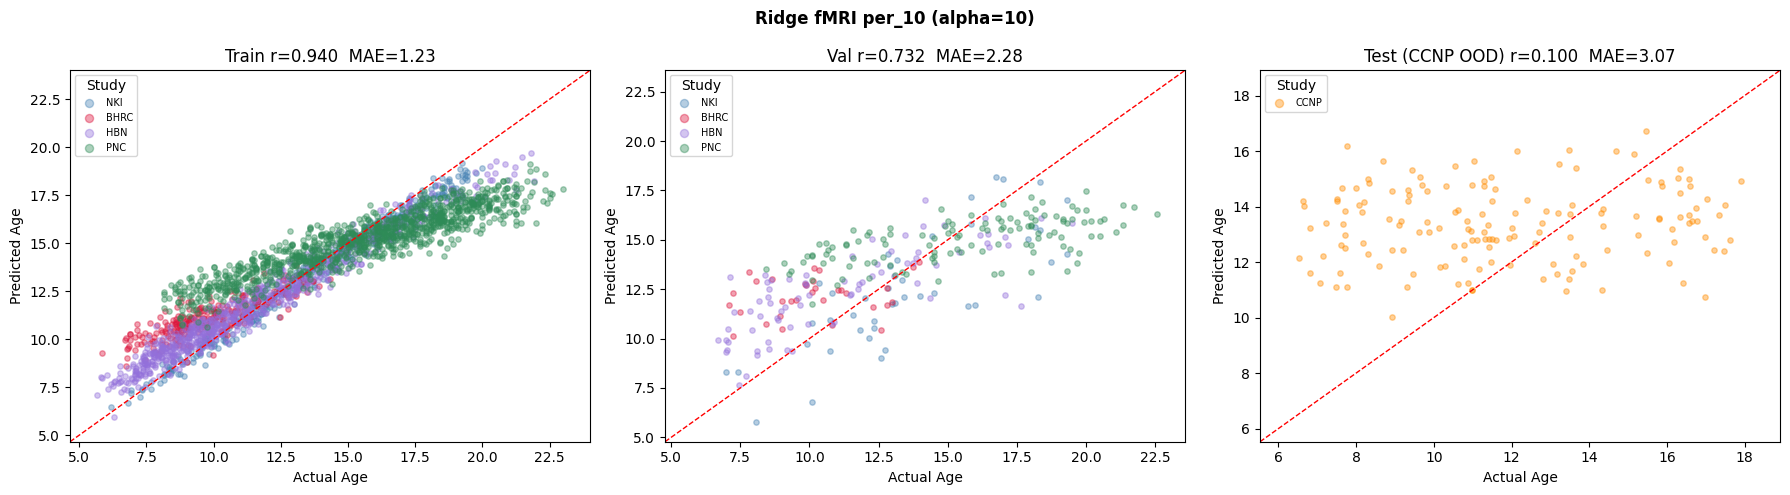

Ridge.fMRI.per_20.0.01                                train r=1.000  | val r=0.722 mae=2.22
Ridge.fMRI.per_20.0.1                                 train r=1.000  | val r=0.723 mae=2.21
Ridge.fMRI.per_20.1                                   train r=0.998  | val r=0.728 mae=2.20
Ridge.fMRI.per_20.10                                  train r=0.952  | val r=0.729 mae=2.26
Ridge.fMRI.per_20.100                                 train r=0.800  | val r=0.649 mae=2.77
Ridge.fMRI.per_20.550                                 train r=0.563  | val r=0.452 mae=3.15
Ridge.fMRI.per_20.1000                                train r=0.458  | val r=0.375 mae=3.22
Ridge.fMRI.per_20.5500                                train r=0.290  | val r=0.262 mae=3.32
Ridge.fMRI.per_20.10000                               train r=0.268  | val r=0.249 mae=3.33
BEST  test r=0.090  MAE=3.05


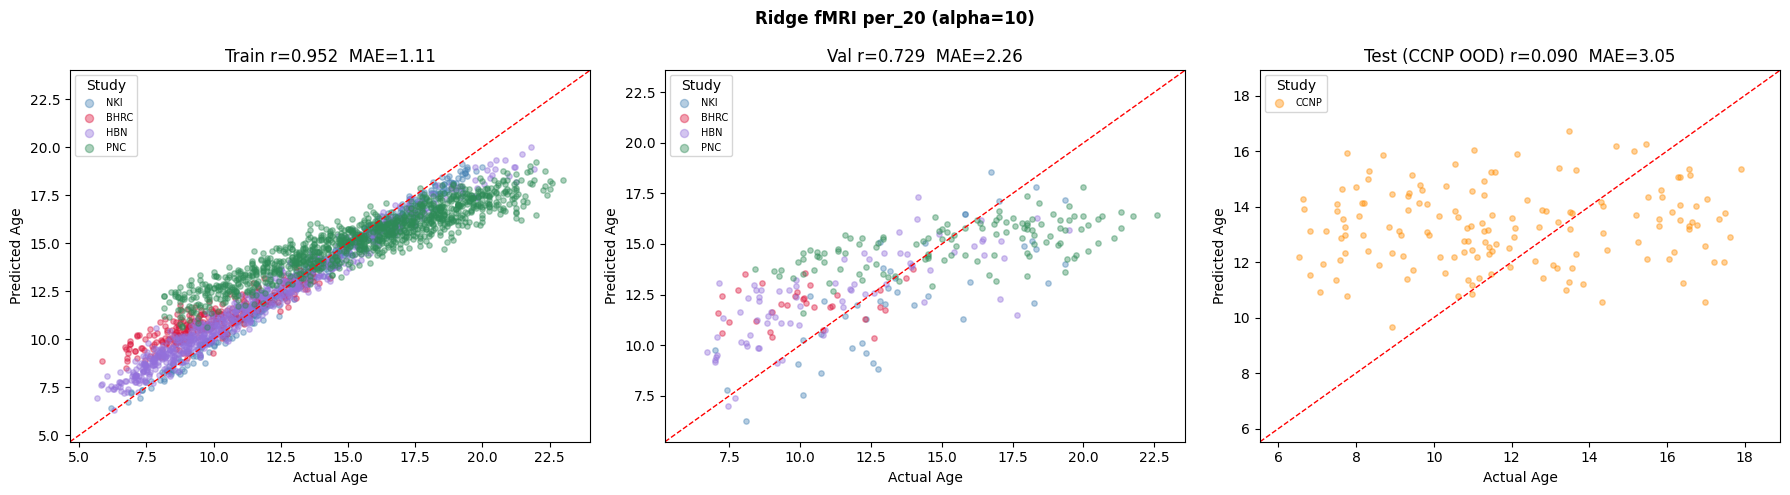

Ridge.fMRI.per_50.0.01                                train r=1.000  | val r=0.734 mae=2.15
Ridge.fMRI.per_50.0.1                                 train r=1.000  | val r=0.735 mae=2.15
Ridge.fMRI.per_50.1                                   train r=0.998  | val r=0.739 mae=2.15
Ridge.fMRI.per_50.10                                  train r=0.951  | val r=0.734 mae=2.25
Ridge.fMRI.per_50.100                                 train r=0.795  | val r=0.641 mae=2.79
Ridge.fMRI.per_50.550                                 train r=0.535  | val r=0.425 mae=3.16
Ridge.fMRI.per_50.1000                                train r=0.422  | val r=0.346 mae=3.22
Ridge.fMRI.per_50.5500                                train r=0.249  | val r=0.234 mae=3.31
Ridge.fMRI.per_50.10000                               train r=0.228  | val r=0.221 mae=3.32
BEST  test r=0.084  MAE=3.09


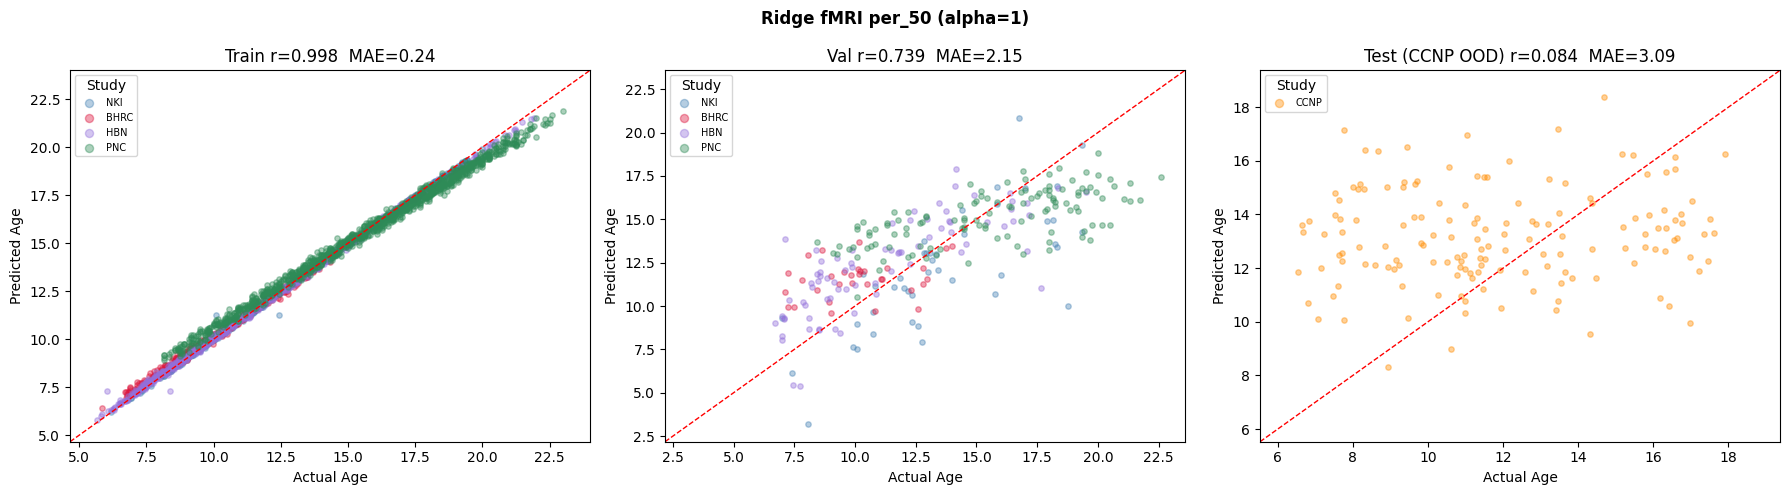

c:\Users\Faruk\miniconda3\envs\ccir_research\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.4691971517730735e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


Ridge.fMRI&sMRI.per_10.0.01                           train r=1.000  | val r=0.729 mae=2.54


c:\Users\Faruk\miniconda3\envs\ccir_research\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.250817298157017e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


Ridge.fMRI&sMRI.per_10.0.1                            train r=1.000  | val r=0.729 mae=2.54
Ridge.fMRI&sMRI.per_10.1                              train r=1.000  | val r=0.734 mae=2.49
Ridge.fMRI&sMRI.per_10.10                             train r=0.996  | val r=0.761 mae=2.28
Ridge.fMRI&sMRI.per_10.100                            train r=0.979  | val r=0.826 mae=1.82
Ridge.fMRI&sMRI.per_10.550                            train r=0.957  | val r=0.868 mae=1.59
Ridge.fMRI&sMRI.per_10.1000                           train r=0.947  | val r=0.878 mae=1.54
Ridge.fMRI&sMRI.per_10.5500                           train r=0.909  | val r=0.884 mae=1.59
Ridge.fMRI&sMRI.per_10.10000                          train r=0.890  | val r=0.875 mae=1.66
BEST  test r=0.133  MAE=3.45


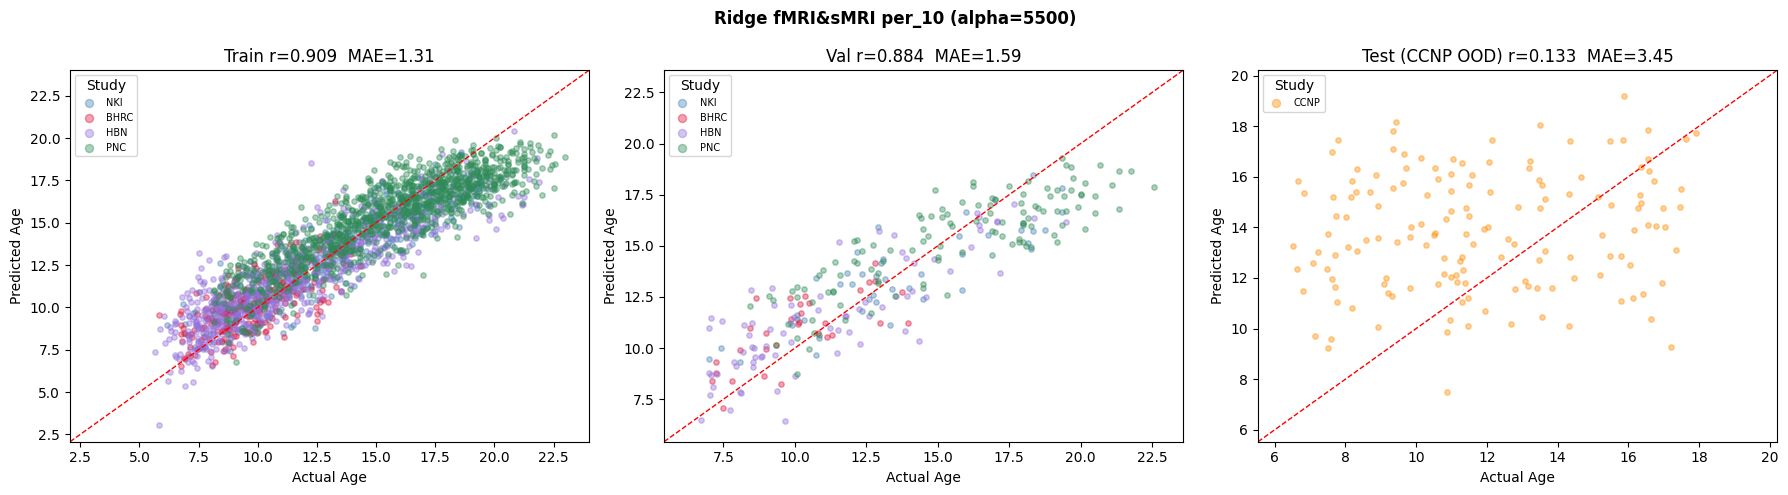

c:\Users\Faruk\miniconda3\envs\ccir_research\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.5168952194908343e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


Ridge.fMRI&sMRI.per_20.0.01                           train r=1.000  | val r=0.735 mae=2.48


c:\Users\Faruk\miniconda3\envs\ccir_research\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.241342566047024e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


Ridge.fMRI&sMRI.per_20.0.1                            train r=1.000  | val r=0.736 mae=2.48
Ridge.fMRI&sMRI.per_20.1                              train r=1.000  | val r=0.740 mae=2.45
Ridge.fMRI&sMRI.per_20.10                             train r=0.997  | val r=0.764 mae=2.26
Ridge.fMRI&sMRI.per_20.100                            train r=0.980  | val r=0.827 mae=1.82
Ridge.fMRI&sMRI.per_20.550                            train r=0.957  | val r=0.869 mae=1.59
Ridge.fMRI&sMRI.per_20.1000                           train r=0.947  | val r=0.878 mae=1.54
Ridge.fMRI&sMRI.per_20.5500                           train r=0.909  | val r=0.884 mae=1.59
Ridge.fMRI&sMRI.per_20.10000                          train r=0.890  | val r=0.875 mae=1.66
BEST  test r=0.133  MAE=3.45


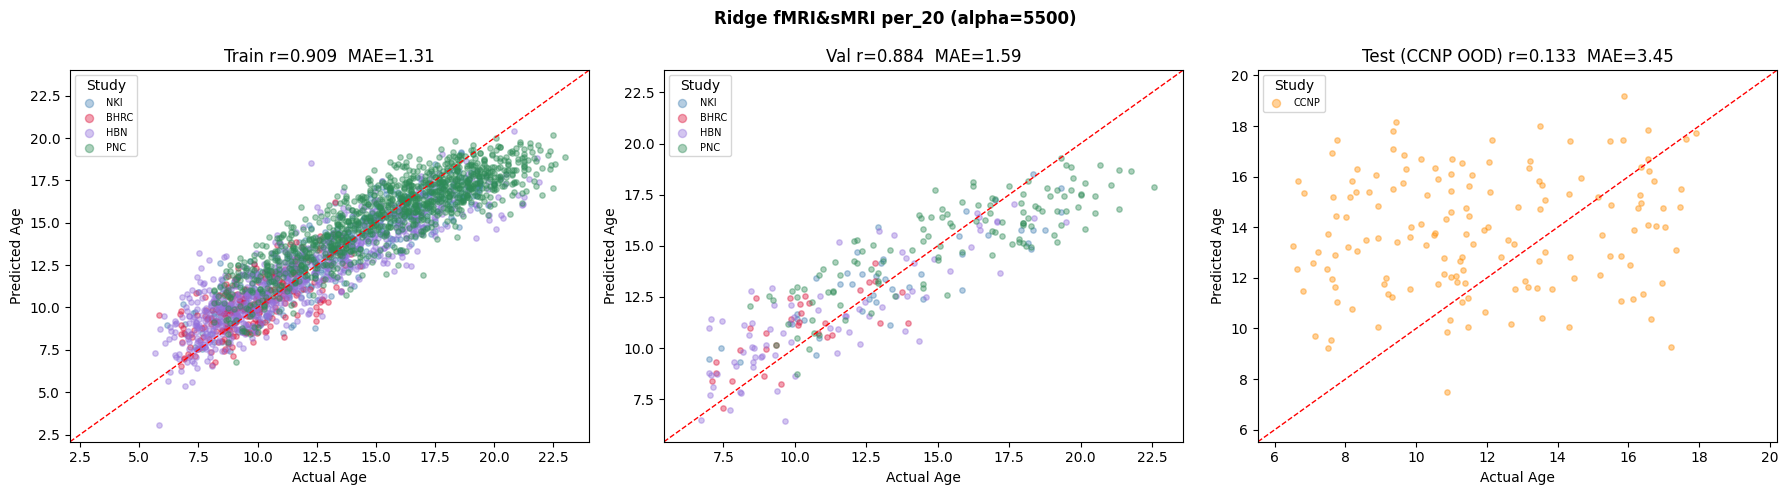

c:\Users\Faruk\miniconda3\envs\ccir_research\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.6810308134960223e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


Ridge.fMRI&sMRI.per_50.0.01                           train r=1.000  | val r=0.736 mae=2.49


c:\Users\Faruk\miniconda3\envs\ccir_research\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.253948304722144e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


Ridge.fMRI&sMRI.per_50.0.1                            train r=1.000  | val r=0.737 mae=2.48
Ridge.fMRI&sMRI.per_50.1                              train r=1.000  | val r=0.741 mae=2.45
Ridge.fMRI&sMRI.per_50.10                             train r=0.997  | val r=0.765 mae=2.25
Ridge.fMRI&sMRI.per_50.100                            train r=0.979  | val r=0.827 mae=1.82
Ridge.fMRI&sMRI.per_50.550                            train r=0.957  | val r=0.869 mae=1.59
Ridge.fMRI&sMRI.per_50.1000                           train r=0.947  | val r=0.878 mae=1.54
Ridge.fMRI&sMRI.per_50.5500                           train r=0.909  | val r=0.884 mae=1.59
Ridge.fMRI&sMRI.per_50.10000                          train r=0.890  | val r=0.875 mae=1.66
BEST  test r=0.133  MAE=3.45


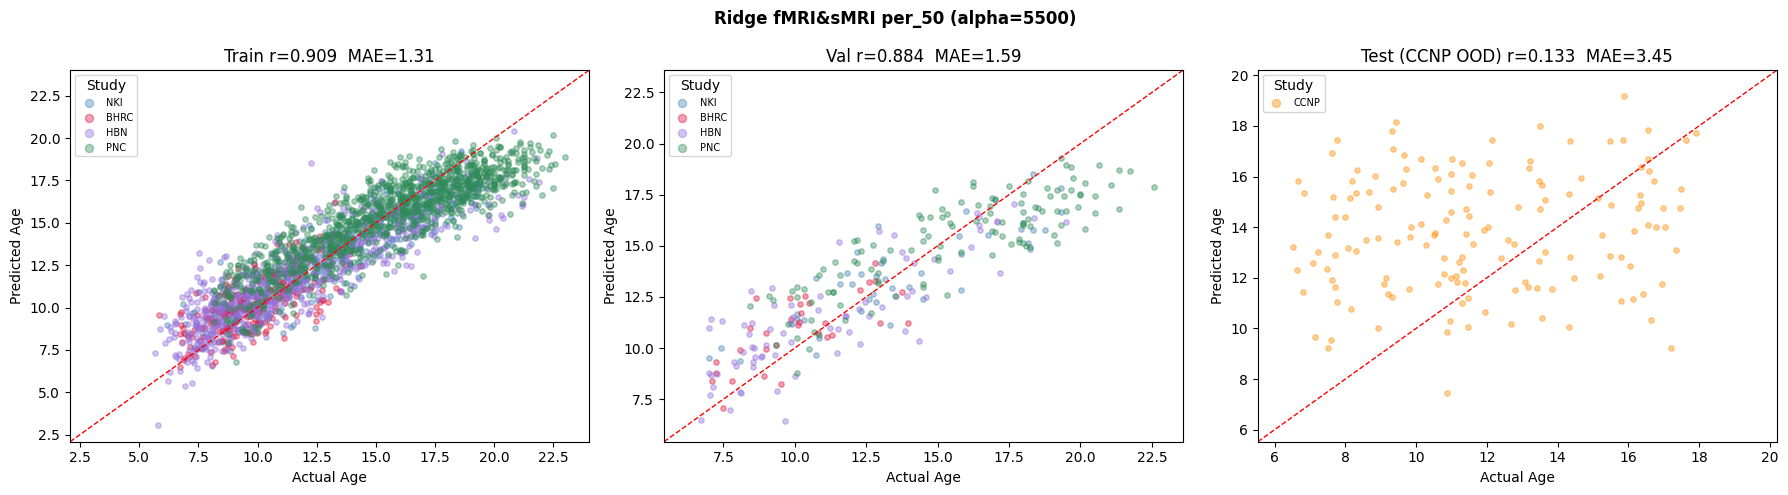

In [ ]:
from sklearn.linear_model import Ridge

_alphas = [0.01, 0.1, 1, 10, 100, 550, 1000, 5500, 10000]

for modality, mod_splits in [("fMRI", splits["fMRI"]), ("fMRI&sMRI", splits["fMRI&sMRI"])]:
    for per, (Xtr, Xvl, Xte) in mod_splits.items():
        if _block_done(f"Ridge.{modality}.{per}."):
            print(f"Skipping Ridge {modality} {per} — already complete")
            continue
        _best_a, _best_vr, _best_model, _best_rv = None, -float("inf"), None, None
        for a in _alphas:
            m = Ridge(alpha=a).fit(Xtr, y_train_bl)
            vr = pearsonr(y_val_bl, m.predict(Xvl))[0]
            rv = _report(name=f"Ridge.{modality}.{per}.{a}", model=m, Xtr=Xtr, Xvl=Xvl)
            if vr > _best_vr:
                _best_a, _best_vr, _best_model, _best_rv = a, vr, m, rv
        _eval_best(_best_rv, _best_model, Xte, title=f"Ridge {modality} {per} (alpha={_best_a:.4g})")
        _results.append(_best_rv)


SVR fMRI per_10: searching 6 params in parallel...


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\1845691373.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  vr = pearsonr(y_val_bl, m.predict(Xvl_sc))[0]


SVR.fMRI.per_10.C1.scale                              train r=0.786  | val r=0.543 mae=2.90


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI.per_10.C1.0.01                               train r=0.902  | val r=nan mae=3.36
SVR.fMRI.per_10.C10.scale                             train r=0.998  | val r=0.708 mae=2.46


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI.per_10.C10.0.01                              train r=1.000  | val r=nan mae=3.37
SVR.fMRI.per_10.C100.scale                            train r=1.000  | val r=0.709 mae=2.45


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI.per_10.C100.0.01                             train r=1.000  | val r=nan mae=3.37
BEST  test r=0.029  MAE=2.92


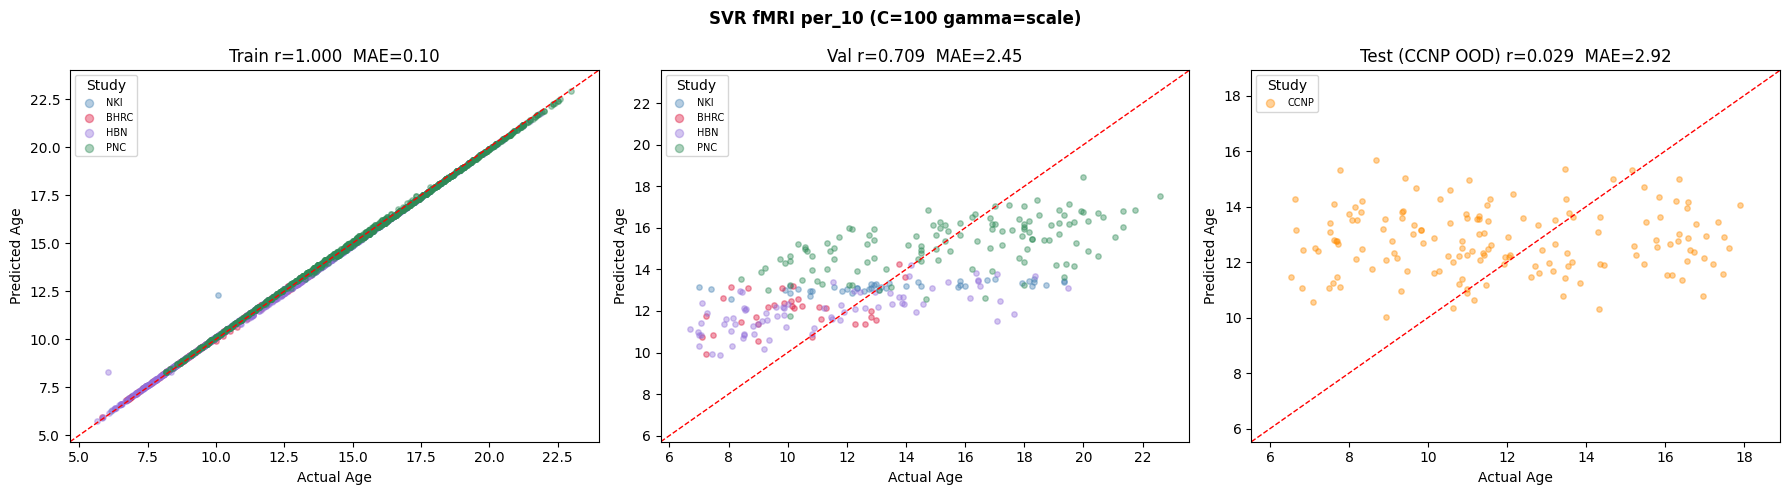

SVR fMRI per_20: searching 6 params in parallel...


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\1845691373.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  vr = pearsonr(y_val_bl, m.predict(Xvl_sc))[0]


SVR.fMRI.per_20.C1.scale                              train r=0.791  | val r=0.599 mae=2.78


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI.per_20.C1.0.01                               train r=0.902  | val r=nan mae=3.36
SVR.fMRI.per_20.C10.scale                             train r=0.998  | val r=0.727 mae=2.36


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI.per_20.C10.0.01                              train r=1.000  | val r=nan mae=3.37
SVR.fMRI.per_20.C100.scale                            train r=1.000  | val r=0.730 mae=2.36


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI.per_20.C100.0.01                             train r=1.000  | val r=nan mae=3.37
BEST  test r=0.052  MAE=2.86


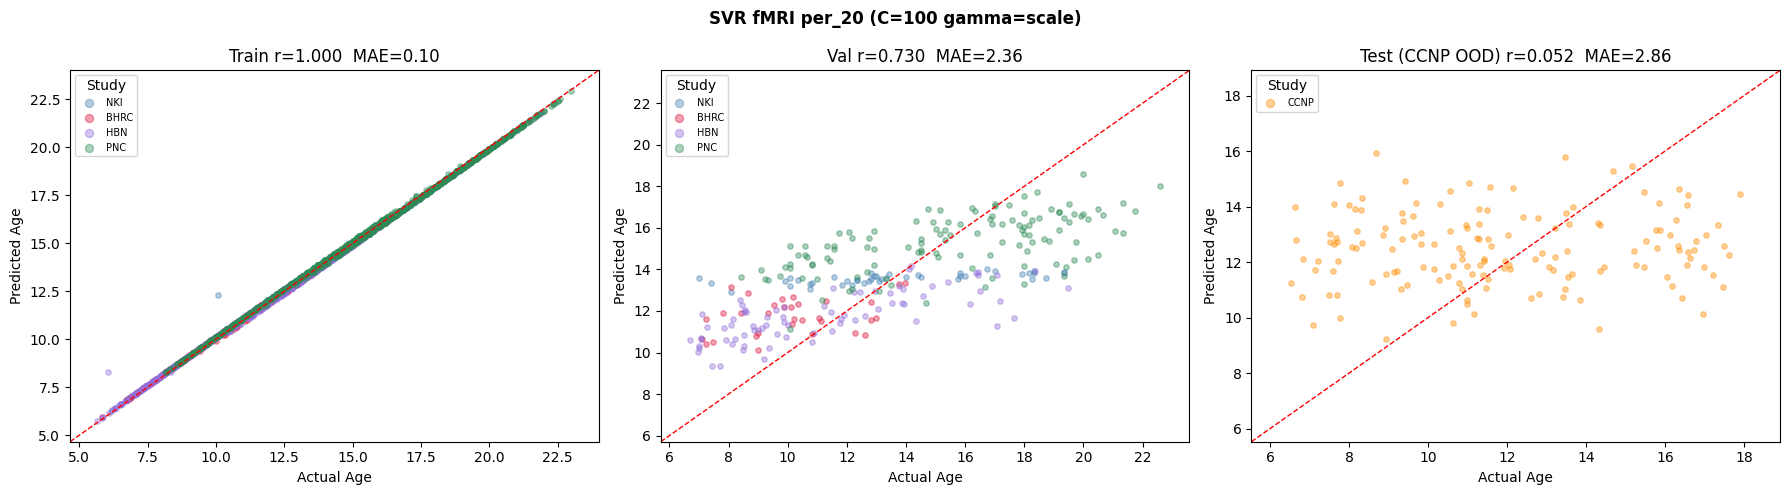

SVR fMRI per_50: searching 6 params in parallel...


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\1845691373.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  vr = pearsonr(y_val_bl, m.predict(Xvl_sc))[0]


SVR.fMRI.per_50.C1.scale                              train r=0.770  | val r=0.622 mae=2.68


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI.per_50.C1.0.01                               train r=0.902  | val r=nan mae=3.36
SVR.fMRI.per_50.C10.scale                             train r=0.997  | val r=0.733 mae=2.30


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI.per_50.C10.0.01                              train r=1.000  | val r=nan mae=3.37
SVR.fMRI.per_50.C100.scale                            train r=1.000  | val r=0.738 mae=2.29


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI.per_50.C100.0.01                             train r=1.000  | val r=nan mae=3.37
BEST  test r=0.031  MAE=2.84


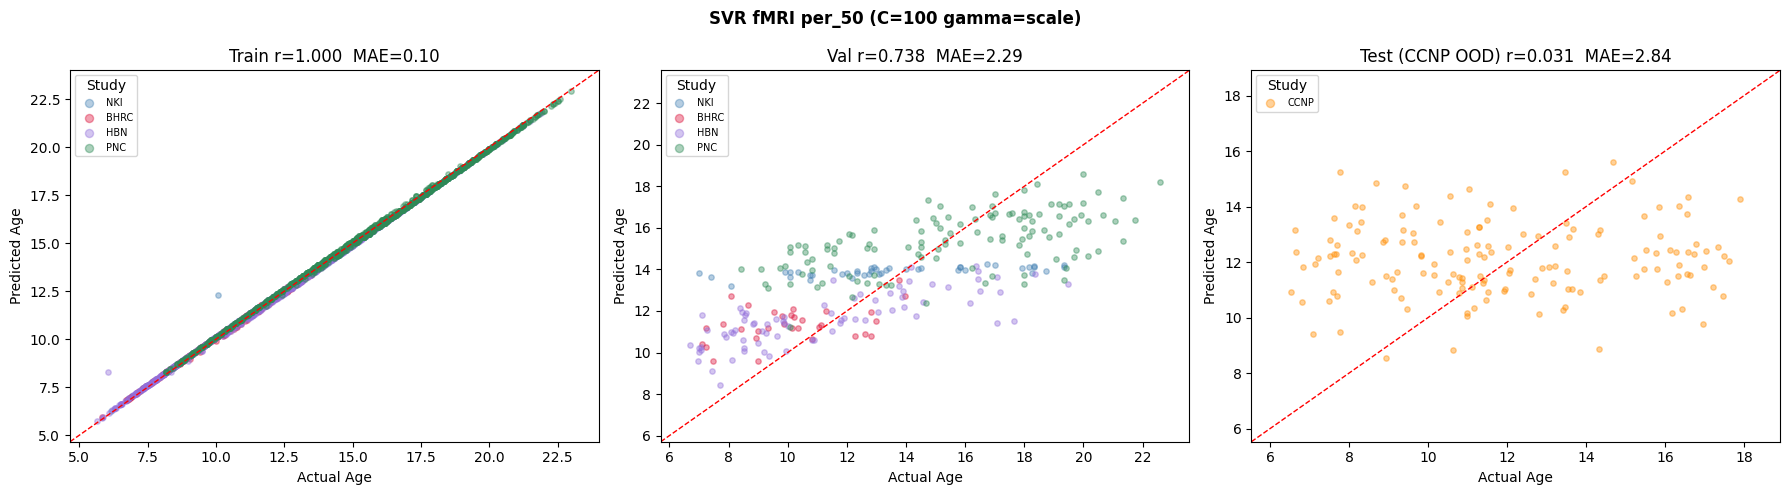

SVR fMRI&sMRI per_10: searching 6 params in parallel...


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\1845691373.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  vr = pearsonr(y_val_bl, m.predict(Xvl_sc))[0]


SVR.fMRI&sMRI.per_10.C1.scale                         train r=0.867  | val r=0.745 mae=2.35


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI&sMRI.per_10.C1.0.01                          train r=0.902  | val r=nan mae=3.36
SVR.fMRI&sMRI.per_10.C10.scale                        train r=1.000  | val r=0.814 mae=1.96


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI&sMRI.per_10.C10.0.01                         train r=1.000  | val r=nan mae=3.37
SVR.fMRI&sMRI.per_10.C100.scale                       train r=1.000  | val r=0.815 mae=1.96


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI&sMRI.per_10.C100.0.01                        train r=1.000  | val r=nan mae=3.37
BEST  test r=0.093  MAE=3.35


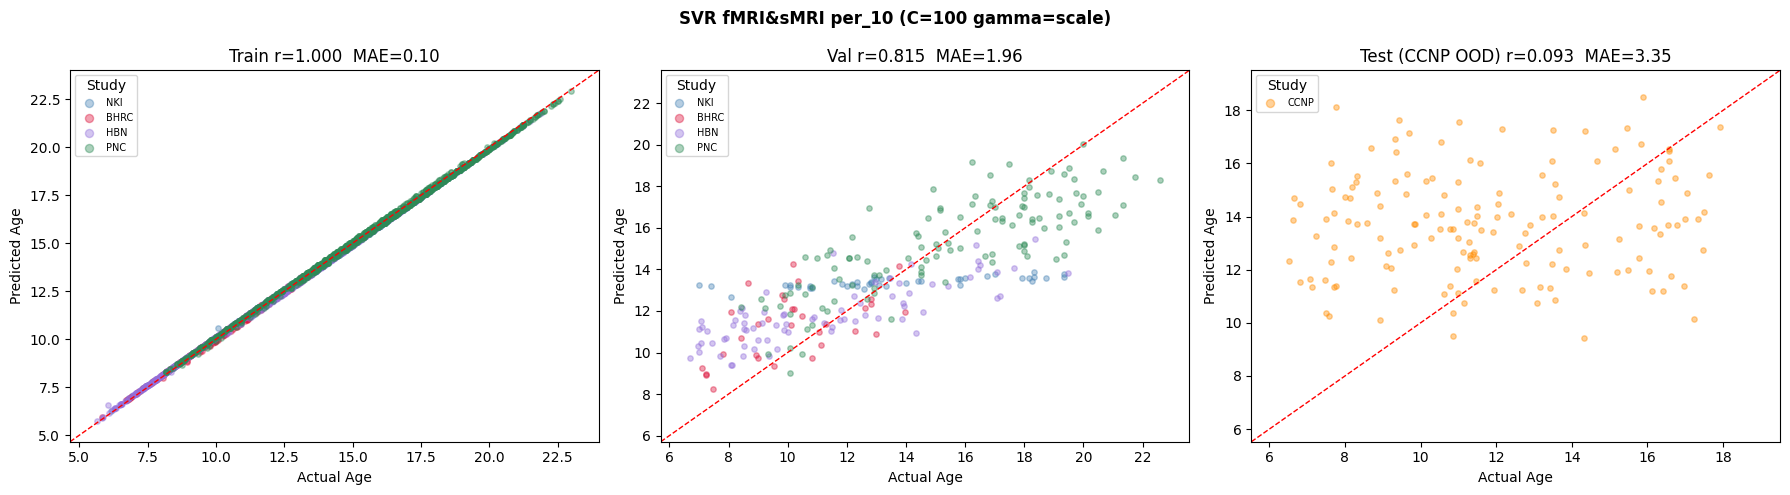

SVR fMRI&sMRI per_20: searching 6 params in parallel...


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\1845691373.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  vr = pearsonr(y_val_bl, m.predict(Xvl_sc))[0]


SVR.fMRI&sMRI.per_20.C1.scale                         train r=0.869  | val r=0.758 mae=2.29


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI&sMRI.per_20.C1.0.01                          train r=0.902  | val r=nan mae=3.36
SVR.fMRI&sMRI.per_20.C10.scale                        train r=1.000  | val r=0.824 mae=1.91


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI&sMRI.per_20.C10.0.01                         train r=1.000  | val r=nan mae=3.37
SVR.fMRI&sMRI.per_20.C100.scale                       train r=1.000  | val r=0.824 mae=1.91


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI&sMRI.per_20.C100.0.01                        train r=1.000  | val r=nan mae=3.37
BEST  test r=0.108  MAE=3.29


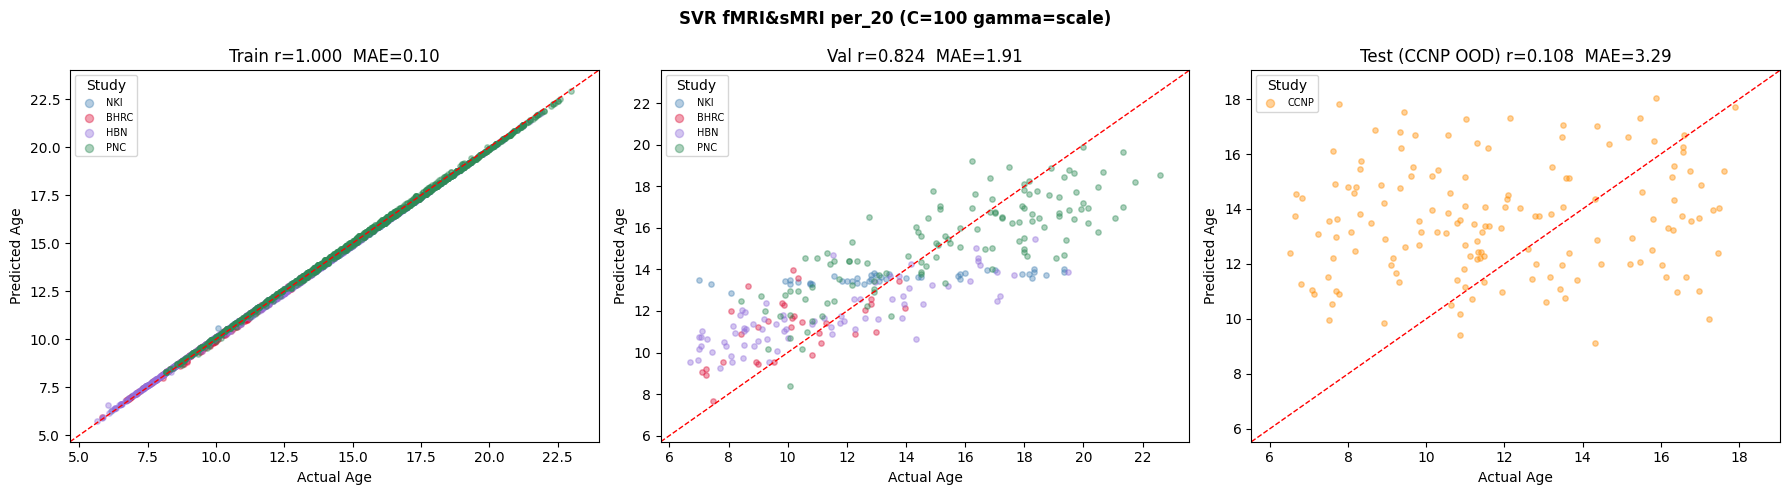

SVR fMRI&sMRI per_50: searching 6 params in parallel...


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\1845691373.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  vr = pearsonr(y_val_bl, m.predict(Xvl_sc))[0]


SVR.fMRI&sMRI.per_50.C1.scale                         train r=0.860  | val r=0.761 mae=2.25


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI&sMRI.per_50.C1.0.01                          train r=0.902  | val r=nan mae=3.36
SVR.fMRI&sMRI.per_50.C10.scale                        train r=0.999  | val r=0.828 mae=1.88


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI&sMRI.per_50.C10.0.01                         train r=1.000  | val r=nan mae=3.37
SVR.fMRI&sMRI.per_50.C100.scale                       train r=1.000  | val r=0.829 mae=1.88


C:\Users\Faruk\AppData\Local\Temp\ipykernel_28324\2831403217.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rv[f"r_{tag}"]   = round(float(pearsonr(y, p)[0]), 3)


SVR.fMRI&sMRI.per_50.C100.0.01                        train r=1.000  | val r=nan mae=3.37
BEST  test r=0.110  MAE=3.23


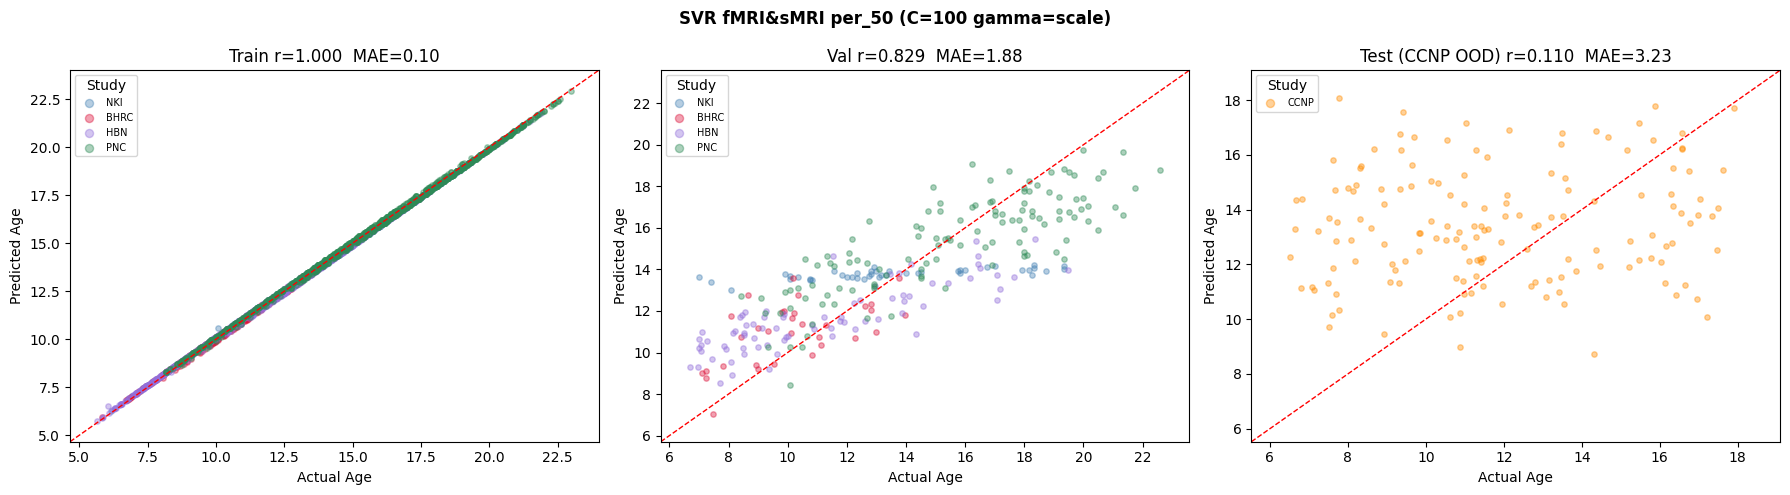

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed

_svr_params = [{"C": c, "gamma": g} for c in [1, 10, 100] for g in ["scale", 0.01]]

def _svr_eval(p, Xtr_sc, Xvl_sc):
    m = SVR(kernel="rbf", **p).fit(Xtr_sc, y_train_bl)
    vr = pearsonr(y_val_bl, m.predict(Xvl_sc))[0]
    return vr, m

for modality, mod_splits in [("fMRI", splits["fMRI"]), ("fMRI&sMRI", splits["fMRI&sMRI"])]:
    for per, (Xtr, Xvl, Xte) in mod_splits.items():
        if _block_done(f"SVR.{modality}.{per}."):
            print(f"Skipping SVR {modality} {per} — already complete")
            continue
        scaler = StandardScaler()
        scaler.fit(np.vstack([Xtr, Xvl]))
        Xtr_sc = scaler.transform(Xtr)
        Xvl_sc = scaler.transform(Xvl)
        Xte_sc = scaler.transform(Xte)
        print(f"SVR {modality} {per}: searching {len(_svr_params)} params in parallel...")
        _best_vr, _best_model, _best_p, _best_rv = -float("inf"), None, None, None
        _res = Parallel(n_jobs=8, prefer="threads")(
            delayed(_svr_eval)(p, Xtr_sc, Xvl_sc) for p in _svr_params
        )
        for (vr, m), p in zip(_res, _svr_params):
            rv = _report(name=f"SVR.{modality}.{per}.C{p['C']}.{p['gamma']}",
                         model=m, Xtr=Xtr_sc, Xvl=Xvl_sc)
            if vr > _best_vr:
                _best_vr, _best_model, _best_p, _best_rv = vr, m, p, rv
        _eval_best(_best_rv, _best_model, Xte_sc,
                   title=f"SVR {modality} {per} (C={_best_p['C']} gamma={_best_p['gamma']})")
        _results.append(_best_rv)


XGB fMRI per_10:   0%|          | 0/12 [00:00<?, ?it/s]

XGB.fMRI.per_10.d4.lr0.05.col0.3                      train r=0.988  | val r=0.730 mae=2.29
XGB.fMRI.per_10.d6.lr0.05.col0.3                      train r=1.000  | val r=0.709 mae=2.38
XGB.fMRI.per_10.d8.lr0.05.col0.3                      train r=1.000  | val r=0.704 mae=2.43
XGB.fMRI.per_10.d4.lr0.1.col0.3                       train r=0.999  | val r=0.722 mae=2.28
XGB.fMRI.per_10.d6.lr0.1.col0.3                       train r=1.000  | val r=0.689 mae=2.43
XGB.fMRI.per_10.d8.lr0.1.col0.3                       train r=1.000  | val r=0.684 mae=2.44
XGB.fMRI.per_10.d4.lr0.05.col0.8                      train r=0.997  | val r=0.730 mae=2.29
XGB.fMRI.per_10.d6.lr0.05.col0.8                      train r=1.000  | val r=0.710 mae=2.37
XGB.fMRI.per_10.d8.lr0.05.col0.8                      train r=1.000  | val r=0.683 mae=2.48
XGB.fMRI.per_10.d4.lr0.1.col0.8                       train r=0.991  | val r=0.687 mae=2.36
XGB.fMRI.per_10.d6.lr0.1.col0.8                       train r=1.000  | val r=0.6

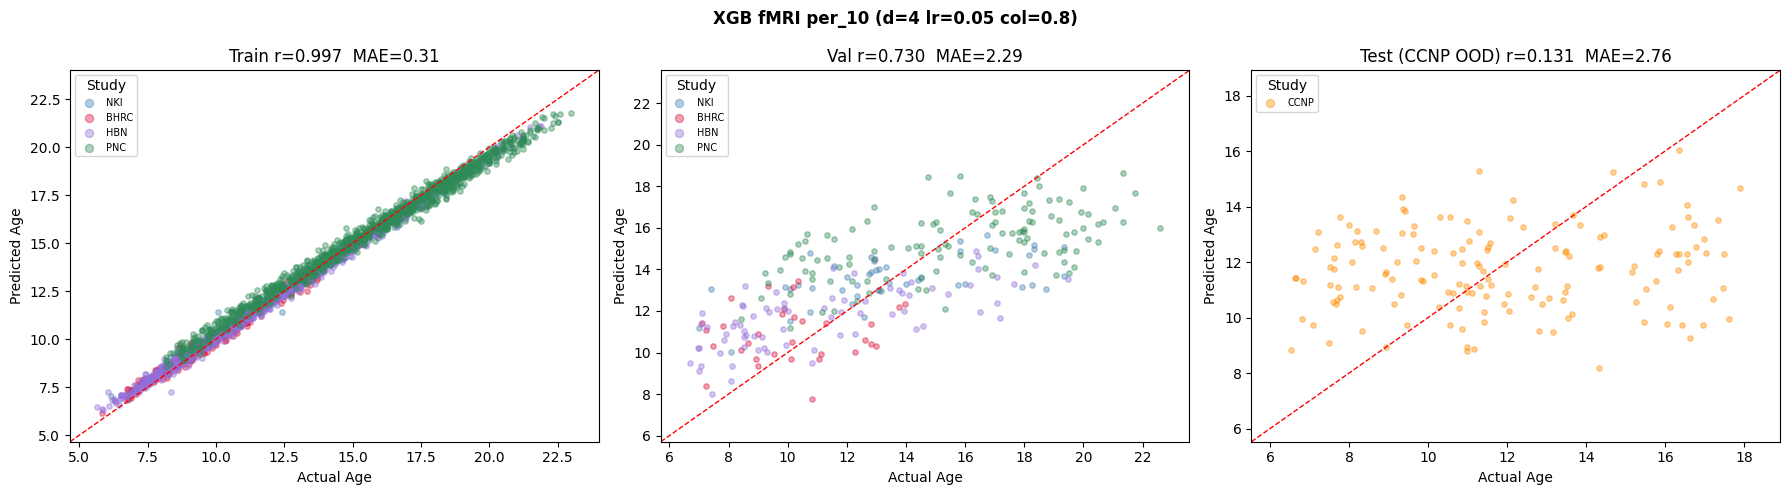

XGB fMRI per_20:   0%|          | 0/12 [00:00<?, ?it/s]

XGB.fMRI.per_20.d4.lr0.05.col0.3                      train r=0.997  | val r=0.741 mae=2.26
XGB.fMRI.per_20.d6.lr0.05.col0.3                      train r=1.000  | val r=0.700 mae=2.45
XGB.fMRI.per_20.d8.lr0.05.col0.3                      train r=1.000  | val r=0.701 mae=2.48
XGB.fMRI.per_20.d4.lr0.1.col0.3                       train r=1.000  | val r=0.710 mae=2.30
XGB.fMRI.per_20.d6.lr0.1.col0.3                       train r=1.000  | val r=0.687 mae=2.44
XGB.fMRI.per_20.d8.lr0.1.col0.3                       train r=1.000  | val r=0.680 mae=2.50
XGB.fMRI.per_20.d4.lr0.05.col0.8                      train r=0.997  | val r=0.726 mae=2.31
XGB.fMRI.per_20.d6.lr0.05.col0.8                      train r=1.000  | val r=0.704 mae=2.40
XGB.fMRI.per_20.d8.lr0.05.col0.8                      train r=1.000  | val r=0.678 mae=2.48
XGB.fMRI.per_20.d4.lr0.1.col0.8                       train r=0.999  | val r=0.676 mae=2.43
XGB.fMRI.per_20.d6.lr0.1.col0.8                       train r=1.000  | val r=0.6

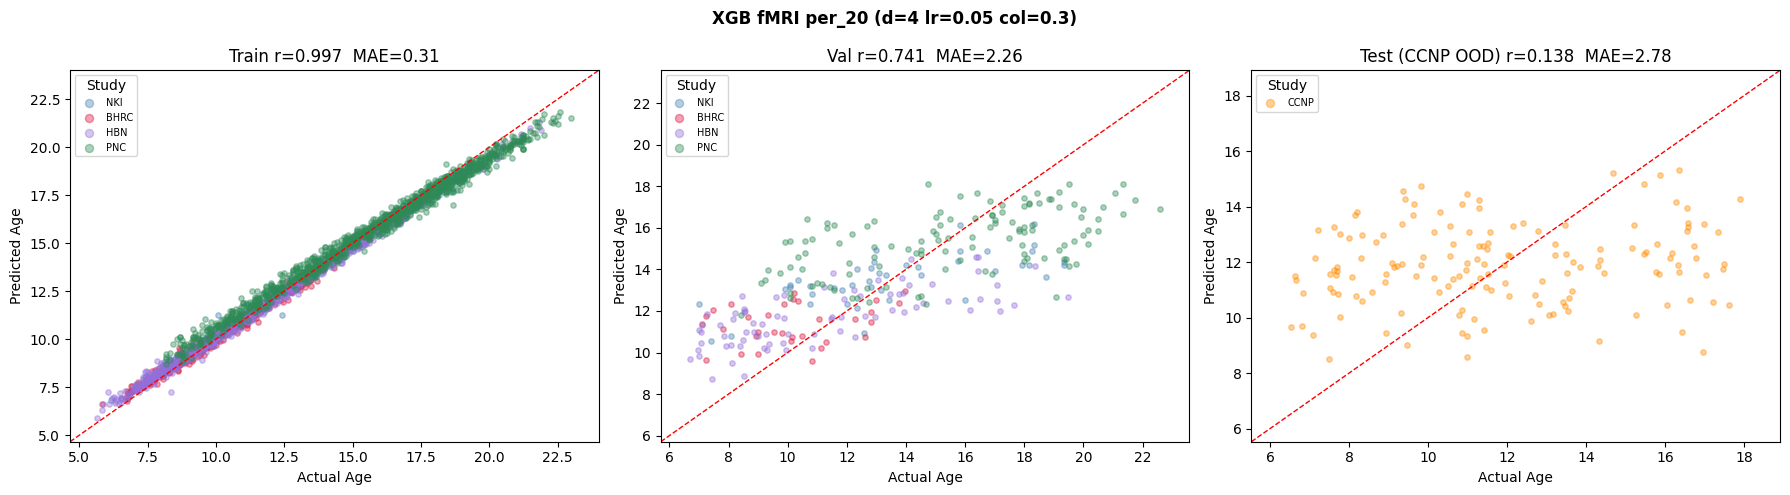

XGB fMRI per_50:   0%|          | 0/12 [00:00<?, ?it/s]

XGB.fMRI.per_50.d4.lr0.05.col0.3                      train r=1.000  | val r=0.720 mae=2.36
XGB.fMRI.per_50.d6.lr0.05.col0.3                      train r=1.000  | val r=0.651 mae=2.59
XGB.fMRI.per_50.d8.lr0.05.col0.3                      train r=1.000  | val r=0.671 mae=2.55
XGB.fMRI.per_50.d4.lr0.1.col0.3                       train r=0.991  | val r=0.667 mae=2.47
XGB.fMRI.per_50.d6.lr0.1.col0.3                       train r=1.000  | val r=0.630 mae=2.57
XGB.fMRI.per_50.d8.lr0.1.col0.3                       train r=1.000  | val r=0.613 mae=2.65
XGB.fMRI.per_50.d4.lr0.05.col0.8                      train r=0.999  | val r=0.719 mae=2.36
XGB.fMRI.per_50.d6.lr0.05.col0.8                      train r=1.000  | val r=0.665 mae=2.52
XGB.fMRI.per_50.d8.lr0.05.col0.8                      train r=1.000  | val r=0.659 mae=2.54
XGB.fMRI.per_50.d4.lr0.1.col0.8                       train r=1.000  | val r=0.710 mae=2.37
XGB.fMRI.per_50.d6.lr0.1.col0.8                       train r=1.000  | val r=0.6

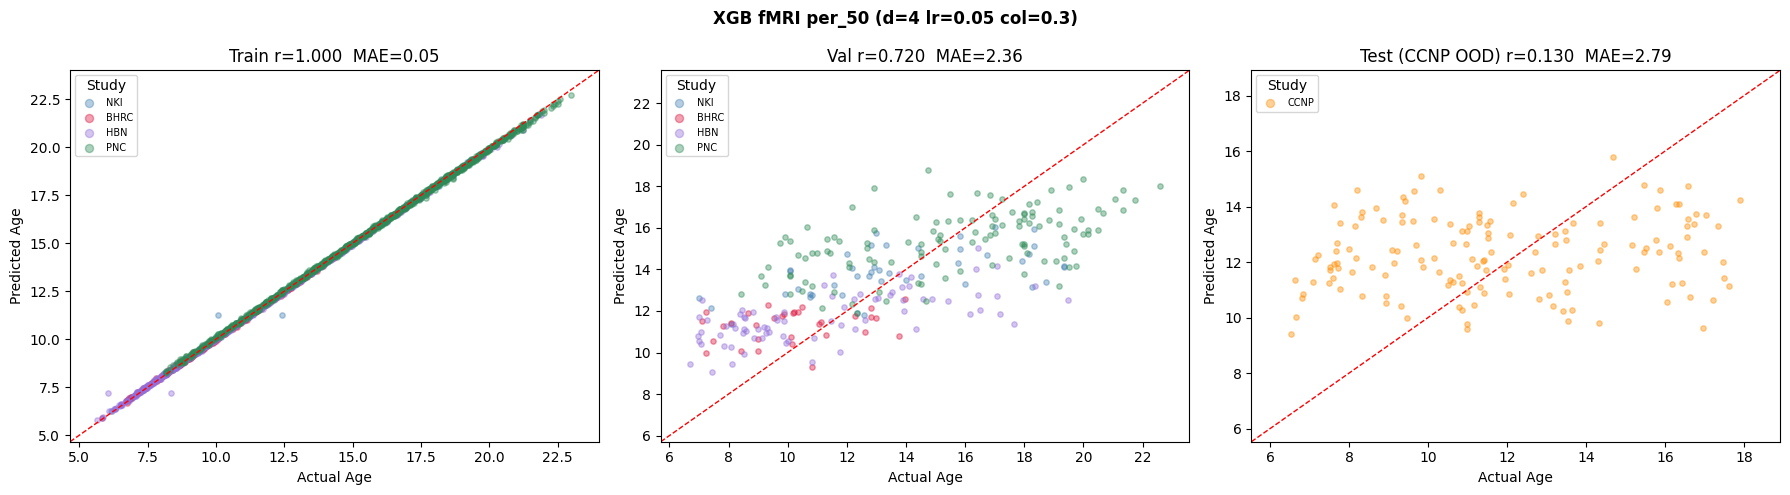

XGB fMRI&sMRI per_10:   0%|          | 0/12 [00:00<?, ?it/s]

XGB.fMRI&sMRI.per_10.d4.lr0.05.col0.3                 train r=0.996  | val r=0.863 mae=1.65
XGB.fMRI&sMRI.per_10.d6.lr0.05.col0.3                 train r=1.000  | val r=0.840 mae=1.80
XGB.fMRI&sMRI.per_10.d8.lr0.05.col0.3                 train r=1.000  | val r=0.824 mae=1.89
XGB.fMRI&sMRI.per_10.d4.lr0.1.col0.3                  train r=1.000  | val r=0.857 mae=1.70
XGB.fMRI&sMRI.per_10.d6.lr0.1.col0.3                  train r=1.000  | val r=0.837 mae=1.82
XGB.fMRI&sMRI.per_10.d8.lr0.1.col0.3                  train r=1.000  | val r=0.803 mae=1.97
XGB.fMRI&sMRI.per_10.d4.lr0.05.col0.8                 train r=0.999  | val r=0.840 mae=1.75
XGB.fMRI&sMRI.per_10.d6.lr0.05.col0.8                 train r=1.000  | val r=0.824 mae=1.85
XGB.fMRI&sMRI.per_10.d8.lr0.05.col0.8                 train r=1.000  | val r=0.799 mae=1.96
XGB.fMRI&sMRI.per_10.d4.lr0.1.col0.8                  train r=1.000  | val r=0.854 mae=1.68
XGB.fMRI&sMRI.per_10.d6.lr0.1.col0.8                  train r=1.000  | val r=0.8

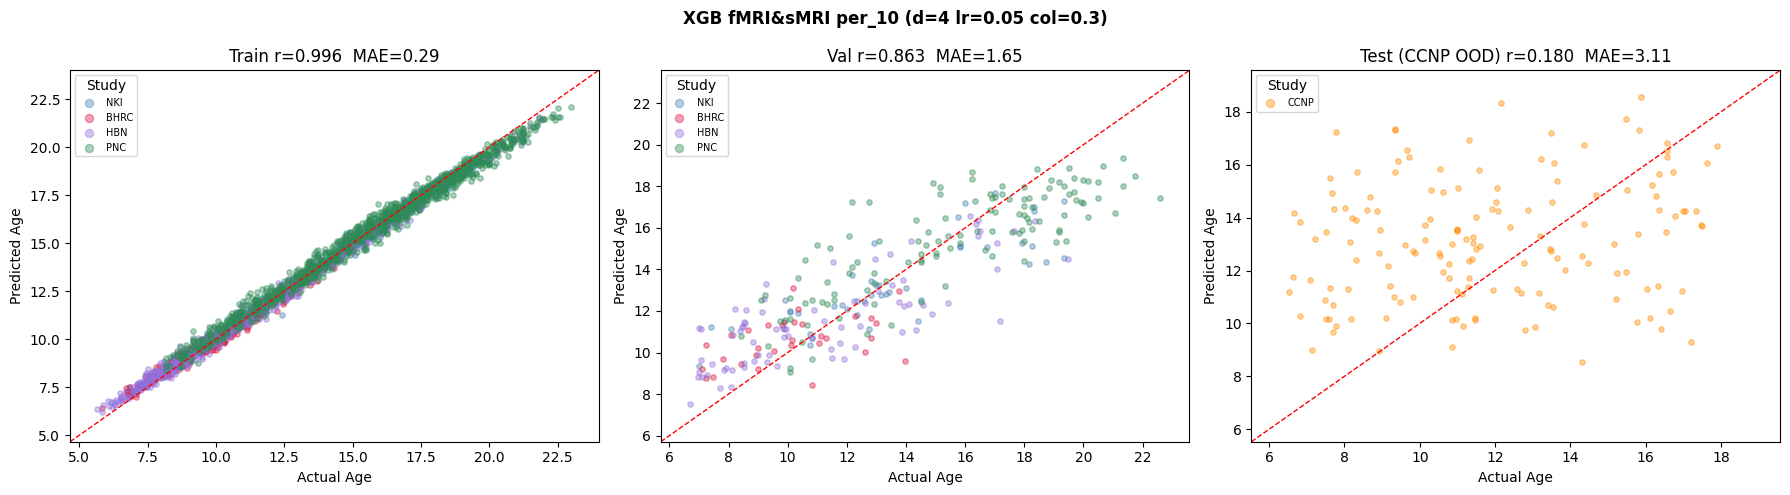

XGB fMRI&sMRI per_20:   0%|          | 0/12 [00:00<?, ?it/s]

XGB.fMRI&sMRI.per_20.d4.lr0.05.col0.3                 train r=0.998  | val r=0.856 mae=1.74
XGB.fMRI&sMRI.per_20.d6.lr0.05.col0.3                 train r=1.000  | val r=0.840 mae=1.84
XGB.fMRI&sMRI.per_20.d8.lr0.05.col0.3                 train r=1.000  | val r=0.810 mae=1.99
XGB.fMRI&sMRI.per_20.d4.lr0.1.col0.3                  train r=0.997  | val r=0.852 mae=1.75
XGB.fMRI&sMRI.per_20.d6.lr0.1.col0.3                  train r=1.000  | val r=0.827 mae=1.87
XGB.fMRI&sMRI.per_20.d8.lr0.1.col0.3                  train r=1.000  | val r=0.800 mae=2.00
XGB.fMRI&sMRI.per_20.d4.lr0.05.col0.8                 train r=1.000  | val r=0.848 mae=1.73
XGB.fMRI&sMRI.per_20.d6.lr0.05.col0.8                 train r=1.000  | val r=0.824 mae=1.85
XGB.fMRI&sMRI.per_20.d8.lr0.05.col0.8                 train r=1.000  | val r=0.797 mae=1.99
XGB.fMRI&sMRI.per_20.d4.lr0.1.col0.8                  train r=0.986  | val r=0.834 mae=1.75
XGB.fMRI&sMRI.per_20.d6.lr0.1.col0.8                  train r=1.000  | val r=0.8

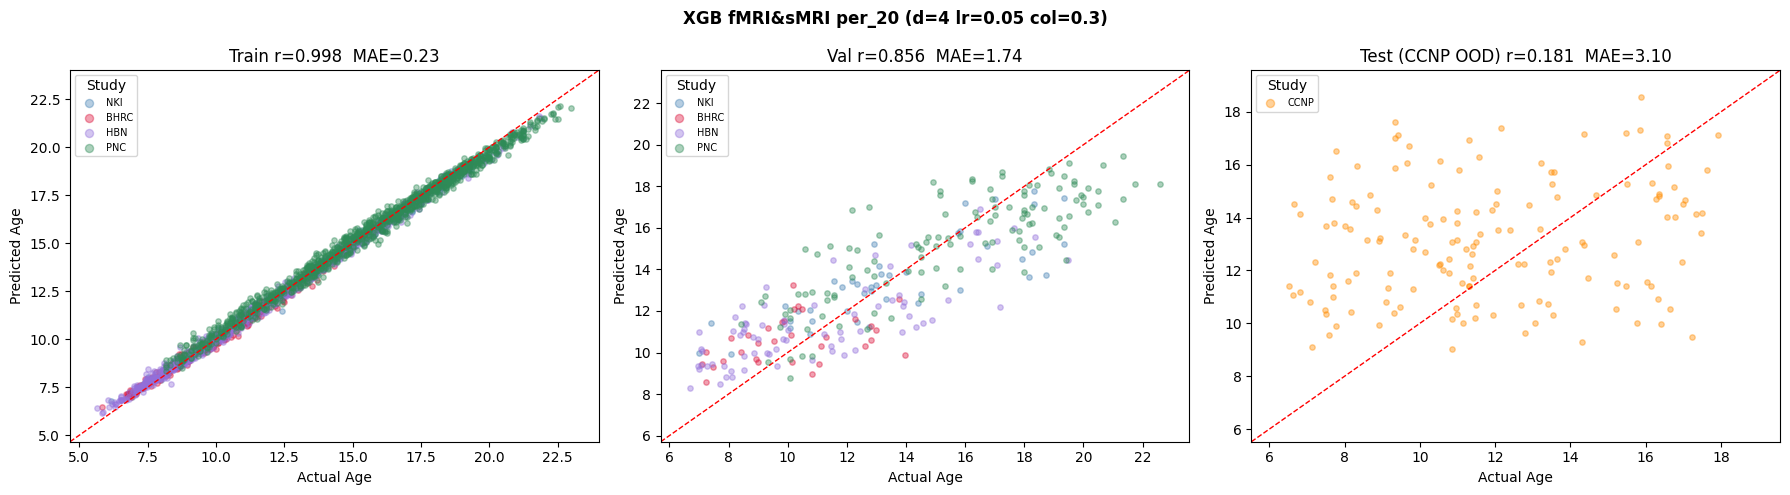

XGB fMRI&sMRI per_50:   0%|          | 0/12 [00:00<?, ?it/s]

XGB.fMRI&sMRI.per_50.d4.lr0.05.col0.3                 train r=1.000  | val r=0.845 mae=1.76
XGB.fMRI&sMRI.per_50.d6.lr0.05.col0.3                 train r=1.000  | val r=0.828 mae=1.88
XGB.fMRI&sMRI.per_50.d8.lr0.05.col0.3                 train r=1.000  | val r=0.803 mae=2.02
XGB.fMRI&sMRI.per_50.d4.lr0.1.col0.3                  train r=0.999  | val r=0.846 mae=1.75
XGB.fMRI&sMRI.per_50.d6.lr0.1.col0.3                  train r=1.000  | val r=0.821 mae=1.90
XGB.fMRI&sMRI.per_50.d8.lr0.1.col0.3                  train r=1.000  | val r=0.804 mae=1.99
XGB.fMRI&sMRI.per_50.d4.lr0.05.col0.8                 train r=0.997  | val r=0.847 mae=1.75
XGB.fMRI&sMRI.per_50.d6.lr0.05.col0.8                 train r=1.000  | val r=0.824 mae=1.88
XGB.fMRI&sMRI.per_50.d8.lr0.05.col0.8                 train r=1.000  | val r=0.787 mae=2.04
XGB.fMRI&sMRI.per_50.d4.lr0.1.col0.8                  train r=1.000  | val r=0.839 mae=1.74
XGB.fMRI&sMRI.per_50.d6.lr0.1.col0.8                  train r=1.000  | val r=0.8

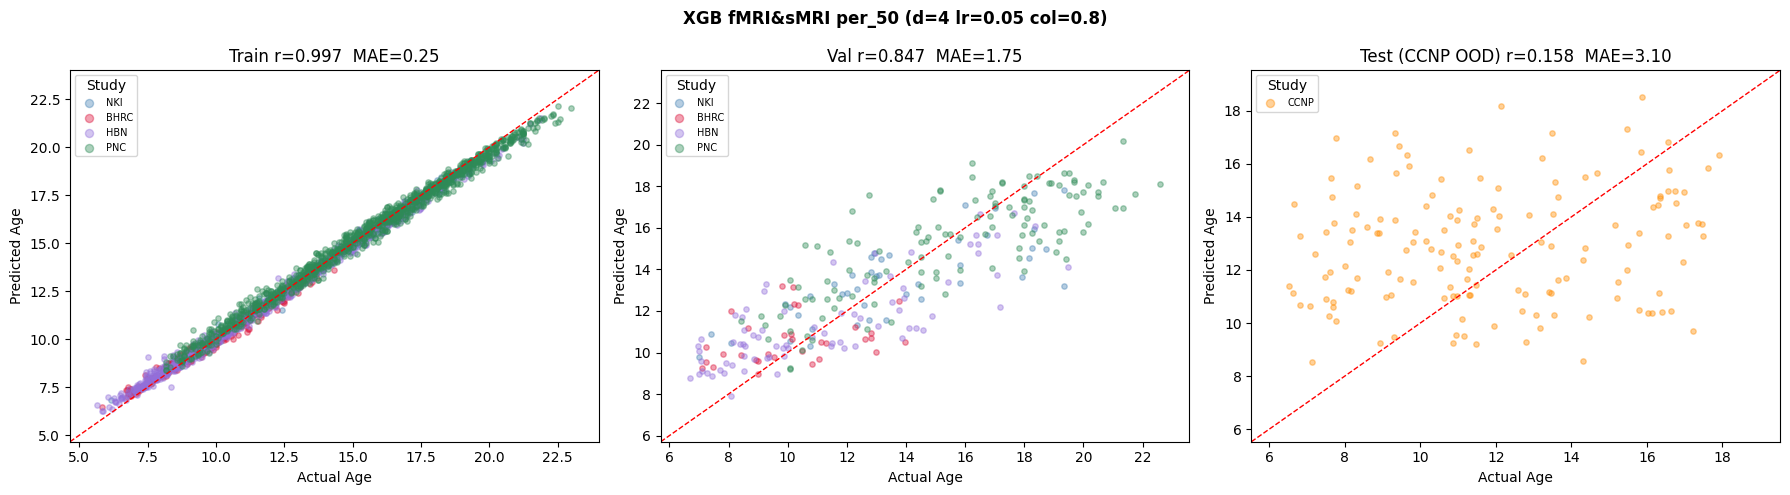

In [4]:
import xgboost as xgb
from sklearn.model_selection import ParameterGrid
from tqdm.notebook import tqdm as tqdm_nb

_xgb_grid = list(ParameterGrid({
    "max_depth":        [4, 6, 8],
    "learning_rate":    [0.05, 0.1],
    "colsample_bytree": [0.3, 0.8],
}))

for modality, mod_splits in [("fMRI", splits["fMRI"]), ("fMRI&sMRI", splits["fMRI&sMRI"])]:
    for per, (Xtr, Xvl, Xte) in mod_splits.items():
        if _block_done(f"XGB.{modality}.{per}."):
            print(f"Skipping XGB {modality} {per} — already complete")
            continue
        _best_vr, _best_model, _best_p, _best_rv = -float("inf"), None, None, None
        for p in tqdm_nb(_xgb_grid, desc=f"XGB {modality} {per}"):
            m = xgb.XGBRegressor(n_estimators=2000, tree_method="hist",
                                  early_stopping_rounds=30, n_jobs=-1,
                                  random_state=42, **p)
            m.fit(Xtr, y_train_bl, eval_set=[(Xvl, y_val_bl)], verbose=False)
            vr = pearsonr(y_val_bl, m.predict(Xvl))[0]
            rv = _report(name=f"XGB.{modality}.{per}.d{p['max_depth']}.lr{p['learning_rate']}.col{p['colsample_bytree']}",
                         model=m, Xtr=Xtr, Xvl=Xvl)
            if vr > _best_vr:
                _best_vr, _best_model, _best_p, _best_rv = vr, m, p, rv
        _eval_best(_best_rv, _best_model, Xte,
                   title=f"XGB {modality} {per} (d={_best_p['max_depth']} lr={_best_p['learning_rate']} col={_best_p['colsample_bytree']})")
        _results.append(_best_rv)


In [ ]:
_rows = []
for r in _results:
    _mod = "fMRI&sMRI" if "fMRI&sMRI" in r["name"] else "fMRI"
    _model = r["name"].split(".")[0]
    _rows.append({"Modality": _mod, "Model": _model,
                  "Val r": r["r_val"], "Val MAE": r["mae_val"],
                  "Test r": r["r_test"], "Test MAE": r["mae_test"]})
pd.DataFrame(_rows).set_index(["Modality", "Model"])